In [ ]:
! pip install scikit-learn-extra --quiet

In [1]:
import pandas as pd
import numpy as np

# Definir número de amostras
n_amostras = 20

# Gerar valores aleatórios para x e y entre 0 e 20 (inclusive)
np.random.seed(42)  # para reprodutibilidade
x = np.random.randint(0, 21, size=n_amostras)
y = np.random.randint(0, 21, size=n_amostras)

# Criar DataFrame
df = pd.DataFrame({'x': x, 'y': y})

# Salvar em CSV
df.to_csv('20_dispositivos.csv', index=False)



In [2]:
# Importar bibliotecas necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.neighbors import NearestNeighbors

In [3]:
# ---------------------------------------------------
# 1. Carregar a base de dados (IoT_5000)
# ---------------------------------------------------
df = pd.read_csv('20_dispositivos.csv')

# ---------------------------------------------------
# 2. Pré-processamento: Normalizar as variáveis
# ---------------------------------------------------
X = df[['x', 'y']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Pos_Devices = X.values

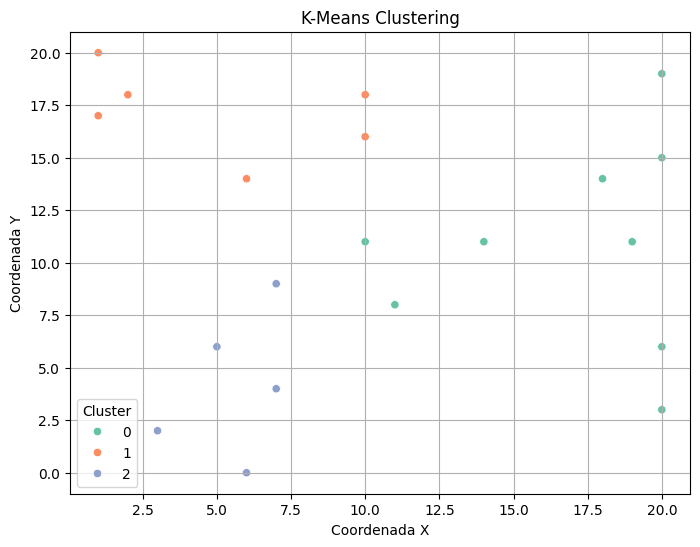

[1 2 0]


In [4]:
# ---------------------------------------------------
# 3. Aplicar K-Means
# ---------------------------------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)
score_kmeans = silhouette_score(X_scaled, df['kmeans_cluster'])

# Visualizar K-Means
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='x', y='y', hue='kmeans_cluster', palette='Set2')
plt.title('K-Means Clustering')
plt.xlabel('Coordenada X')
plt.ylabel('Coordenada Y')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

#print('Silhouette Score (K-Means):', round(score_kmeans, 3))

# KMeans com inicialização aleatória
kmeans = KMeans(n_clusters=3, init='random', random_state=0)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Distancia dos Centroides e o PB
# Obter centróides
centroids = kmeans.cluster_centers_

# Calcular distâncias até (0,0)
distancias = np.linalg.norm(centroids, axis=1)

# Obter ordem crescente de proximidade
ordem_clusters = np.argsort(distancias)

print(ordem_clusters)

indices_por_cluster = {}

for cluster_id in sorted(df['kmeans_cluster'].unique()):
    indices = df[df['kmeans_cluster'] == cluster_id].index.tolist()
    indices_por_cluster[cluster_id] = indices

In [5]:
indices_por_cluster

{np.int32(0): [1, 2, 5, 7, 9, 10, 14, 16, 19],
 np.int32(1): [3, 6, 8, 13, 15, 18],
 np.int32(2): [0, 4, 11, 12, 17]}

In [6]:
# Inicializa vetor de índices ordenados
indices_ordenados = []

# Itera sobre os clusters na ordem desejada
for cluster_id in ordem_clusters:
    # Pega os índices dos elementos pertencentes a esse cluster
    indices = df[df['kmeans_cluster'] == cluster_id].index.tolist()
    # Adiciona ao vetor final
    indices_ordenados.extend(indices)

indice_devices = np.array(indices_ordenados)


In [7]:
print(indice_devices)

[ 3  6  8 13 15 18  0  4 11 12 17  1  2  5  7  9 10 14 16 19]


Clusterização: o K-Means agrupou dispositivos que têm perfil semelhante de posição e consumo.

Ordem entre clusters: carregamos primeiro o cluster cuja média de distância ao PB é menor (menor path‐loss, logo maior eficiência).

Ordem dentro do cluster: entre os “próximos”, carregamos primeiro os mais próximos ao PB (minimizando perdas e equilibrando o sistema).

In [8]:
# ---------- 2) Definir parâmetros do modelo WET ----------
N = 10                                # número de antenas
K = 20               # número de dispositivos
k_rice = 1.5                         # Fator de Rice
c = 3e8                              # velocidade da luz (m/s)
f = 9.15e8                           # frequência (Hz)
max_pot = 10.73e-3                   # potência máxima de transmissão
a = 0.238
b = 5.365
omega = 1 / np.exp(a * b)            # constante ω
alpha = 2.7                          # expoente de perda de percurso
Pt = 3                               # potência de transmissão total
Em = 1e-6                            # energia mínima coletada

def new_func(K, N):
    """
    Gera uma matriz (K x N) cujos elementos são números complexos,
    cada parte (real e imaginária) ~ N(0,1).
    """
    return np.random.normal(0, 1, (K, N)) + 1j * np.random.normal(0, 1, (K, N))

# Gera as matrizes de canal
h_barra = new_func(K, N)                    # K x N complexa
h_barra_aux = new_func(K, N)
h_til = h_barra_aux * (1 / np.sqrt(2))       # Rayleigh
h_k = (np.sqrt(k_rice / (1 + k_rice)) * h_barra +
       np.sqrt(1 / (1 + k_rice)) * h_til)     # shape: (K, N)

# Vetor de distâncias (já calculadas em df_reordered['euclid_dist'])
d_k = np.zeros((K))
beta_k = np.zeros((K))

for k_idx in range(K):
  k = indice_devices[k_idx]
  d_k[k_idx] = np.sqrt(Pos_Devices[k,0]**2 + Pos_Devices[k,1]**2)
  beta_k[k_idx] = (c**2) / (16 * np.pi**2 * f**2 * (d_k[k_idx]**alpha))  # vetor de tamanho K

# ---------- 3) Construir a matriz Ψ (respeitando a ordem “pos→k”) ----------
Psi = np.zeros((K, N), dtype=complex)
for pos in range(K):
    k = indice_devices[pos]
    for antenna in range(N):
        fase_unit = h_k[k, antenna] / np.abs(h_k[k, antenna])
        Psi[pos, antenna] = np.sqrt(Pt / N) * fase_unit

# Hermitiano de h_k: conjugado transposto (N x K)
h_k_hermitiano = np.conjugate(h_k).T

# ---------- 4) Inicializar arrays para armazenar resultados ----------
prod_in = np.zeros(K, dtype=complex)            # produto interno para cada dispositivo
P_k = np.zeros(K)                          # potências P_k (cada dispositivo visto por cada outro)
phi = np.zeros(K)                               # φ para cada dispositivo (próprio)
T_k = np.zeros(K)                               # T_k para cada dispositivo
prod_in_neig = np.zeros((K, K), dtype=complex)  # produto interno k→j
P_neig = np.zeros((K, K))                       # potências P_k visto j
phi_neig = np.zeros((K, K))                     # φ_neig[k,j]
phi_neig_total = np.zeros(K)                    # soma de φ_neig por k
phi_s = np.zeros(K)                             # φ_s final (próprio + vizinhos)

# ---------- 5) Loop principal para cálculo de φ_s (respeitando ordem) ----------
for pos in range(K):
    k = indice_devices[pos]  # índice real do dispositivo que está na posição pos

    # 5.1) Cálculo para o próprio dispositivo (j == k)
    prod_in[pos] = np.dot(Psi[pos], h_k_hermitiano[:, k])
    absoluto = np.abs(prod_in[pos])**2
    P_neig[pos, pos] = beta_k[pos] * absoluto

    # 5.2) Cálculo das interferências de todos os j que já carregaram (prev_pos < pos):
    for prev_pos in range(K):
        j = indice_devices[prev_pos]
        prod_in_neig[pos, prev_pos] = np.dot(Psi[pos], h_k_hermitiano[:, j])
        absoluto_neig = np.abs(prod_in_neig[pos, prev_pos])**2
        P_neig[pos, prev_pos] = beta_k[j] * absoluto_neig


    # Somatório das interferências de todos os j para o dispositivo k
    phi_s[pos] = np.sum(P_neig[pos,:])

# ---------- 6) Armazenar φ_s em df_reordered e exibir soma total ----------
print(f"\nSoma total de φ_s (todos os dispositivos): {np.sum(phi_s)}")


Soma total de φ_s (todos os dispositivos): 0.00744554115447206


Silhouette Score (DBSCAN): 0.752


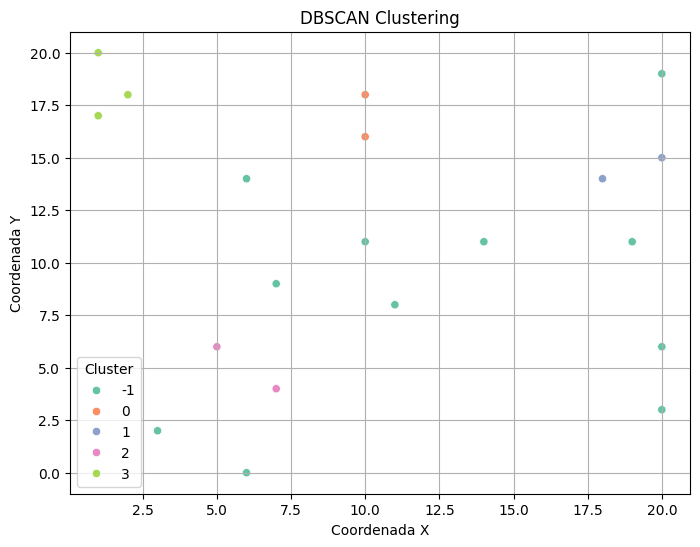

Ordem de clusters por proximidade ao PB: [2, 3, 0, 1]
Índices por cluster na ordem de atendimento:
  Cluster 2: [12, 17]
  Cluster 3: [13, 15, 18]
  Cluster 0: [3, 8]
  Cluster 1: [5, 7]


In [56]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# 3. Aplicar DBSCAN
# ---------------------------------------------------
# Ajuste estes parâmetros conforme o seu problema
dbscan = DBSCAN(eps=0.5, min_samples=2)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

# Calcular Silhouette Score (somente para os pontos não-ruído e se existirem ≥2 clusters)
labels = df['dbscan_cluster']
mask = labels != -1  # remove ruído
clusters_reais = set(labels[mask])
if len(clusters_reais) > 1:
    score_dbscan = silhouette_score(X_scaled[mask], labels[mask])
    print('Silhouette Score (DBSCAN):', round(score_dbscan, 3))
else:
    print('Silhouette Score (DBSCAN): não é possível calcular (menos de 2 clusters encontrados)')

# ---------------------------------------------------
# Visualizar DBSCAN
# ---------------------------------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x='x', y='y',
    hue='dbscan_cluster',
    palette='Set2',
    legend='full'
)
plt.title('DBSCAN Clustering')
plt.xlabel('Coordenada X')
plt.ylabel('Coordenada Y')
plt.grid(True)
plt.legend(title='Cluster', loc='best')
plt.show()

# ---------------------------------------------------
# Centróides aproximados e distâncias ao PB em (0,0)
# ---------------------------------------------------
# Como o DBSCAN não fornece centróides, calculamos a média de cada cluster (ignorando ruído)
centroids = (
    df[df['dbscan_cluster'] != -1]
    .groupby('dbscan_cluster')[['x', 'y']]
    .mean()
)

# Calcular distâncias dos centróides ao ponto (0,0)
distancias = np.linalg.norm(centroids.values, axis=1)

# Ordenar clusters pela distância crescente
ordem_clusters = centroids.index[np.argsort(distancias)].tolist()
print('Ordem de clusters por proximidade ao PB:', ordem_clusters)

# Obter índices de dispositivo em cada cluster, na ordem definida
indices_por_cluster = {
    cl: df[df['dbscan_cluster'] == cl].index.tolist()
    for cl in ordem_clusters
}

print('Índices por cluster na ordem de atendimento:')
for cl, idxs in indices_por_cluster.items():
    print(f'  Cluster {cl}: {idxs}')



In [40]:
indices_por_cluster

{2: [12, 17], 3: [13, 15, 18], 0: [3, 8], 1: [5, 7]}

In [46]:
# Inicializa vetor de índices ordenados
indices_ordenados = []

# Itera sobre os clusters na ordem desejada
for cluster_id in ordem_clusters:
    # Pega os índices dos elementos pertencentes a esse cluster
    indices = df[df['dbscan_cluster'] == cluster_id].index.tolist()
    # Adiciona ao vetor final
    indices_ordenados.extend(indices)

indice_devices = np.array(indices_ordenados)
# 1) Todos os clusters, inclusive o ruído (-1)
clusters_unicos = sorted(df['dbscan_cluster'].unique())  # ex: [-1, 0, 1, 2]

# 2) Índices de cada cluster
indices_por_cluster = {
    cl: df[df['dbscan_cluster'] == cl].index.tolist()
    for cl in clusters_unicos
}

# 3) Ordenar os clusters “válidos” por distância do centróide ao PB
#    (calcula centróides só para cl != -1)
validos = [cl for cl in clusters_unicos if cl != -1]
centroids = (
    df[df['dbscan_cluster'].isin(validos)]
      .groupby('dbscan_cluster')[['x','y']]
      .mean()
)
ordem_validos = centroids.index[np.argsort(np.linalg.norm(centroids.values, axis=1))].tolist()

#    Coloca o ruído por último (se existir)
ordem_clusters = ordem_validos + ([-1] if -1 in clusters_unicos else [])

# 4) Monta o vetor de índices na ordem desejada
indices_ordenados = []
for cl in ordem_clusters:
    indices_ordenados.extend(indices_por_cluster[cl])

indice_devices = np.array(indices_ordenados)

print("clusters na ordem:", ordem_clusters)
print("indice_devices:", indice_devices)
# agora indice_devices terá exatamente K posições, sem estourar índices


clusters na ordem: [2, 3, 0, 1, -1]
indice_devices: [12 17 13 15 18  3  8  5  7  0  1  2  4  6  9 10 11 14 16 19]


In [47]:
print(indice_devices)

[12 17 13 15 18  3  8  5  7  0  1  2  4  6  9 10 11 14 16 19]


In [48]:
# ---------- 2) Definir parâmetros do modelo WET ----------
N = 10                                # número de antenas
K = 20               # número de dispositivos
k_rice = 1.5                         # Fator de Rice
c = 3e8                              # velocidade da luz (m/s)
f = 9.15e8                           # frequência (Hz)
max_pot = 10.73e-3                   # potência máxima de transmissão
a = 0.238
b = 5.365
omega = 1 / np.exp(a * b)            # constante ω
alpha = 2.7                          # expoente de perda de percurso
Pt = 3                               # potência de transmissão total
Em = 1e-6                            # energia mínima coletada

def new_func(K, N):
    """
    Gera uma matriz (K x N) cujos elementos são números complexos,
    cada parte (real e imaginária) ~ N(0,1).
    """
    return np.random.normal(0, 1, (K, N)) + 1j * np.random.normal(0, 1, (K, N))

# Gera as matrizes de canal
h_barra = new_func(K, N)                    # K x N complexa
h_barra_aux = new_func(K, N)
h_til = h_barra_aux * (1 / np.sqrt(2))       # Rayleigh
h_k = (np.sqrt(k_rice / (1 + k_rice)) * h_barra +
       np.sqrt(1 / (1 + k_rice)) * h_til)     # shape: (K, N)

# Vetor de distâncias (já calculadas em df_reordered['euclid_dist'])
d_k = np.zeros((K))
beta_k = np.zeros((K))

for k_idx in range(K):
  k = indice_devices[k_idx]
  d_k[k_idx] = np.sqrt(Pos_Devices[k,0]**2 + Pos_Devices[k,1]**2)
  beta_k[k_idx] = (c**2) / (16 * np.pi**2 * f**2 * (d_k[k_idx]**alpha))  # vetor de tamanho K

# ---------- 3) Construir a matriz Ψ (respeitando a ordem “pos→k”) ----------
Psi = np.zeros((K, N), dtype=complex)
for pos in range(K):
    k = indice_devices[pos]
    for antenna in range(N):
        fase_unit = h_k[k, antenna] / np.abs(h_k[k, antenna])
        Psi[pos, antenna] = np.sqrt(Pt / N) * fase_unit

# Hermitiano de h_k: conjugado transposto (N x K)
h_k_hermitiano = np.conjugate(h_k).T

# ---------- 4) Inicializar arrays para armazenar resultados ----------
prod_in = np.zeros(K, dtype=complex)            # produto interno para cada dispositivo
P_k = np.zeros(K)                          # potências P_k (cada dispositivo visto por cada outro)
phi = np.zeros(K)                               # φ para cada dispositivo (próprio)
T_k = np.zeros(K)                               # T_k para cada dispositivo
prod_in_neig = np.zeros((K, K), dtype=complex)  # produto interno k→j
P_neig = np.zeros((K, K))                       # potências P_k visto j
phi_neig = np.zeros((K, K))                     # φ_neig[k,j]
phi_neig_total = np.zeros(K)                    # soma de φ_neig por k
phi_s = np.zeros(K)                             # φ_s final (próprio + vizinhos)

# ---------- 5) Loop principal para cálculo de φ_s (respeitando ordem) ----------
for pos in range(K):
    k = indice_devices[pos]  # índice real do dispositivo que está na posição pos

    # 5.1) Cálculo para o próprio dispositivo (j == k)
    prod_in[pos] = np.dot(Psi[pos], h_k_hermitiano[:, k])
    absoluto = np.abs(prod_in[pos])**2
    P_neig[pos, pos] = beta_k[pos] * absoluto

    # 5.2) Cálculo das interferências de todos os j que já carregaram (prev_pos < pos):
    for prev_pos in range(K):
        j = indice_devices[prev_pos]
        prod_in_neig[pos, prev_pos] = np.dot(Psi[pos], h_k_hermitiano[:, j])
        absoluto_neig = np.abs(prod_in_neig[pos, prev_pos])**2
        P_neig[pos, prev_pos] = beta_k[j] * absoluto_neig


    # Somatório das interferências de todos os j para o dispositivo k
    phi_s[pos] = np.sum(P_neig[pos,:])

# ---------- 6) Armazenar φ_s em df_reordered e exibir soma total ----------
print(f"\nSoma total de φ_s (todos os dispositivos): {np.sum(phi_s)}")


Soma total de φ_s (todos os dispositivos): 0.007933034195464116


Silhouette Score (Hierárquico): 0.377


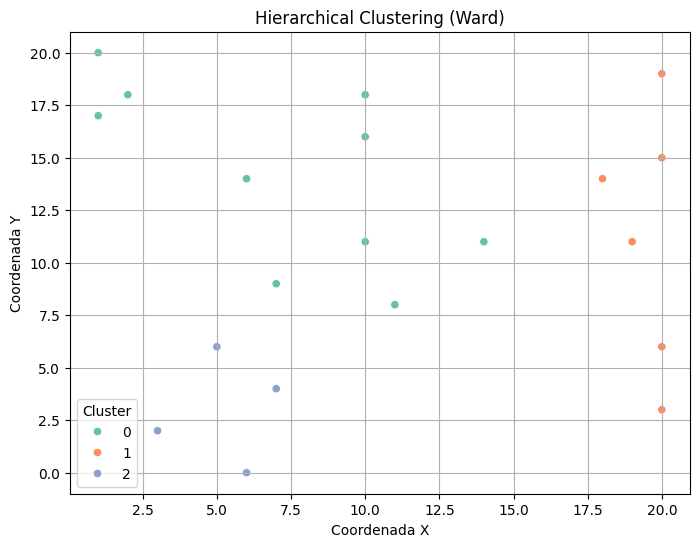

Ordem de clusters por proximidade ao PB: [2, 0, 1]
Índices por cluster na ordem de atendimento:
  Cluster 2: [0, 11, 12, 17]
  Cluster 0: [2, 3, 4, 6, 8, 9, 13, 15, 16, 18]
  Cluster 1: [1, 5, 7, 10, 14, 19]


In [17]:
# ---------------------------------------------------
# 3. Aplicar Clusterização Hierárquica Aglomerativa
# ---------------------------------------------------
# Configure linkage='ward' (minimiza variância interna) ou outro método: 'complete', 'average', 'single'
hier = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['hier_cluster'] = hier.fit_predict(X_scaled)

# Calcular Silhouette Score (requer ≥2 clusters)
if len(set(df['hier_cluster'])) > 1:
    score_hier = silhouette_score(X_scaled, df['hier_cluster'])
    print('Silhouette Score (Hierárquico):', round(score_hier, 3))
else:
    print('Silhouette Score (Hierárquico): não é possível calcular (menos de 2 clusters)')

# ---------------------------------------------------
# Visualizar Clusterização Hierárquica
# ---------------------------------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x='x', y='y',
    hue='hier_cluster',
    palette='Set2',
    legend='full'
)
plt.title('Hierarchical Clustering (Ward)')
plt.xlabel('Coordenada X')
plt.ylabel('Coordenada Y')
plt.grid(True)
plt.legend(title='Cluster', loc='best')
plt.show()

# ---------------------------------------------------
# Centróides Aproximados e Distâncias ao PB em (0,0)
# ---------------------------------------------------
# Calculamos o "centroide" de cada cluster como a média de x e y
centroids = (
    df
    .groupby('hier_cluster')[['x', 'y']]
    .mean()
)

# Distâncias dos centróides ao ponto PB (0,0)
distancias = np.linalg.norm(centroids.values, axis=1)

# Ordenar índices de clusters pela distância crescente
ordem_clusters = centroids.index[np.argsort(distancias)].tolist()
print('Ordem de clusters por proximidade ao PB:', ordem_clusters)

# Obter índices de dispositivos em cada cluster, na ordem de atendimento
indices_por_cluster = {
    cl: df[df['hier_cluster'] == cl].index.tolist()
    for cl in ordem_clusters
}

print('Índices por cluster na ordem de atendimento:')
for cl, idxs in indices_por_cluster.items():
    print(f'  Cluster {cl}: {idxs}')

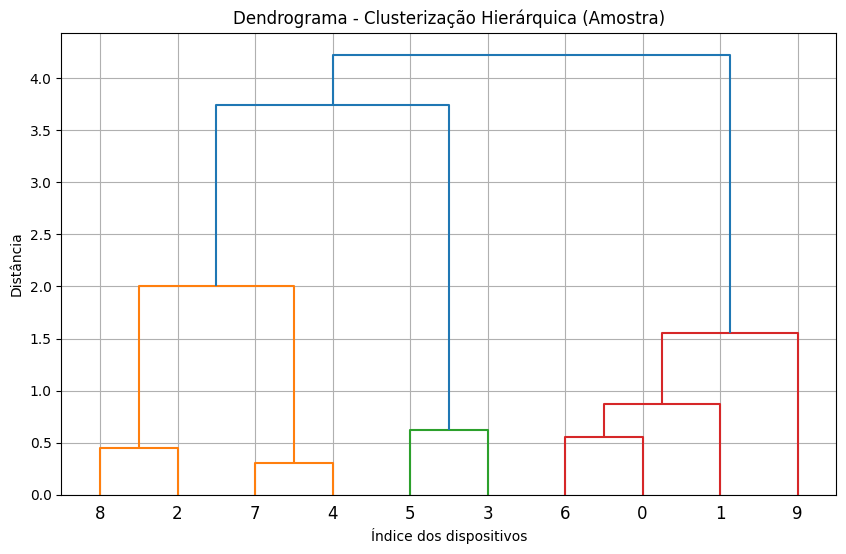

In [54]:
# ---------------------------------------------------
# 7. Dendrograma Hierárquico para Exploração
# ---------------------------------------------------
# Selecionar pequena amostra para visualização
df_sample = df.sample(n=10, random_state=42)
X_sample_scaled = scaler.fit_transform(df_sample[['x', 'y']])
linked = linkage(X_sample_scaled, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title("Dendrograma - Clusterização Hierárquica (Amostra)")
plt.xlabel("Índice dos dispositivos")
plt.ylabel("Distância")
plt.grid(True)
plt.show()

In [18]:
indices_por_cluster

{2: [0, 11, 12, 17],
 0: [2, 3, 4, 6, 8, 9, 13, 15, 16, 18],
 1: [1, 5, 7, 10, 14, 19]}

In [26]:
indices_ordenados = []

for cluster_id in ordem_clusters:
    mask = (df['hier_cluster'] == cluster_id)
    print(f"cluster_id={cluster_id:>1}  → {mask.sum()} linhas encontradas:  ", np.where(mask)[0])
    indices_ordenados.extend(np.where(mask)[0].tolist())

indice_devices = np.array(indices_ordenados)
print("resultado final:", indice_devices)


cluster_id=2  → 4 linhas encontradas:   [ 0 11 12 17]
cluster_id=0  → 10 linhas encontradas:   [ 2  3  4  6  8  9 13 15 16 18]
cluster_id=1  → 6 linhas encontradas:   [ 1  5  7 10 14 19]
resultado final: [ 0 11 12 17  2  3  4  6  8  9 13 15 16 18  1  5  7 10 14 19]


In [27]:
print(indice_devices)

[ 0 11 12 17  2  3  4  6  8  9 13 15 16 18  1  5  7 10 14 19]


In [28]:
# ---------- 2) Definir parâmetros do modelo WET ----------
N = 10                                # número de antenas
K = 20               # número de dispositivos
k_rice = 1.5                         # Fator de Rice
c = 3e8                              # velocidade da luz (m/s)
f = 9.15e8                           # frequência (Hz)
max_pot = 10.73e-3                   # potência máxima de transmissão
a = 0.238
b = 5.365
omega = 1 / np.exp(a * b)            # constante ω
alpha = 2.7                          # expoente de perda de percurso
Pt = 3                               # potência de transmissão total
Em = 1e-6                            # energia mínima coletada

def new_func(K, N):
    """
    Gera uma matriz (K x N) cujos elementos são números complexos,
    cada parte (real e imaginária) ~ N(0,1).
    """
    return np.random.normal(0, 1, (K, N)) + 1j * np.random.normal(0, 1, (K, N))

# Gera as matrizes de canal
h_barra = new_func(K, N)                    # K x N complexa
h_barra_aux = new_func(K, N)
h_til = h_barra_aux * (1 / np.sqrt(2))       # Rayleigh
h_k = (np.sqrt(k_rice / (1 + k_rice)) * h_barra +
       np.sqrt(1 / (1 + k_rice)) * h_til)     # shape: (K, N)

# Vetor de distâncias (já calculadas em df_reordered['euclid_dist'])
d_k = np.zeros((K))
beta_k = np.zeros((K))

for k_idx in range(K):
  k = indice_devices[k_idx]
  d_k[k_idx] = np.sqrt(Pos_Devices[k,0]**2 + Pos_Devices[k,1]**2)
  beta_k[k_idx] = (c**2) / (16 * np.pi**2 * f**2 * (d_k[k_idx]**alpha))  # vetor de tamanho K

# ---------- 3) Construir a matriz Ψ (respeitando a ordem “pos→k”) ----------
Psi = np.zeros((K, N), dtype=complex)
for pos in range(K):
    k = indice_devices[pos]
    for antenna in range(N):
        fase_unit = h_k[k, antenna] / np.abs(h_k[k, antenna])
        Psi[pos, antenna] = np.sqrt(Pt / N) * fase_unit

# Hermitiano de h_k: conjugado transposto (N x K)
h_k_hermitiano = np.conjugate(h_k).T

# ---------- 4) Inicializar arrays para armazenar resultados ----------
prod_in = np.zeros(K, dtype=complex)            # produto interno para cada dispositivo
P_k = np.zeros(K)                          # potências P_k (cada dispositivo visto por cada outro)
phi = np.zeros(K)                               # φ para cada dispositivo (próprio)
T_k = np.zeros(K)                               # T_k para cada dispositivo
prod_in_neig = np.zeros((K, K), dtype=complex)  # produto interno k→j
P_neig = np.zeros((K, K))                       # potências P_k visto j
phi_neig = np.zeros((K, K))                     # φ_neig[k,j]
phi_neig_total = np.zeros(K)                    # soma de φ_neig por k
phi_s = np.zeros(K)                             # φ_s final (próprio + vizinhos)

# ---------- 5) Loop principal para cálculo de φ_s (respeitando ordem) ----------
for pos in range(K):
    k = indice_devices[pos]  # índice real do dispositivo que está na posição pos

    # 5.1) Cálculo para o próprio dispositivo (j == k)
    prod_in[pos] = np.dot(Psi[pos], h_k_hermitiano[:, k])
    absoluto = np.abs(prod_in[pos])**2
    P_neig[pos, pos] = beta_k[pos] * absoluto

    # 5.2) Cálculo das interferências de todos os j que já carregaram (prev_pos < pos):
    for prev_pos in range(K):
        j = indice_devices[prev_pos]
        prod_in_neig[pos, prev_pos] = np.dot(Psi[pos], h_k_hermitiano[:, j])
        absoluto_neig = np.abs(prod_in_neig[pos, prev_pos])**2
        P_neig[pos, prev_pos] = beta_k[j] * absoluto_neig


    # Somatório das interferências de todos os j para o dispositivo k
    phi_s[pos] = np.sum(P_neig[pos,:])

# ---------- 6) Armazenar φ_s em df_reordered e exibir soma total ----------
print(f"\nSoma total de φ_s (todos os dispositivos): {np.sum(phi_s)}")


Soma total de φ_s (todos os dispositivos): 0.004680009282739718


In [9]:
# ALEATÓRIO

indice_devices = np.arange(K)

# Vetor de distâncias (já calculadas em df_reordered['euclid_dist'])
d_k = np.zeros((K))
beta_k = np.zeros((K))

for k_idx in range(K):
  d_k[k_idx] = np.sqrt(Pos_Devices[k_idx,0]**2 + Pos_Devices[k_idx,1]**2)
  beta_k[k_idx] = (c**2) / (16 * np.pi**2 * f**2 * (d_k[k_idx]**alpha))  # vetor de tamanho K

# ---------- 3) Construir a matriz Ψ (respeitando a ordem “pos→k”) ----------
Psi = np.zeros((K, N), dtype=complex)
for pos in range(K):
    for antenna in range(N):
        fase_unit = h_k[pos, antenna] / np.abs(h_k[pos, antenna])
        Psi[pos, antenna] = np.sqrt(Pt / N) * fase_unit

# Hermitiano de h_k: conjugado transposto (N x K)
h_k_hermitiano = np.conjugate(h_k).T

# ---------- 4) Inicializar arrays para armazenar resultados ----------
prod_in = np.zeros(K, dtype=complex)            # produto interno para cada dispositivo
P_k = np.zeros((K, K))                          # potências P_k (cada dispositivo visto por cada outro)
phi = np.zeros(K)                               # φ para cada dispositivo (próprio)
T_k = np.zeros(K)                               # T_k para cada dispositivo
prod_in_neig = np.zeros((K, K), dtype=complex)  # produto interno k→j
P_neig = np.zeros((K, K))                       # potências P_k visto j
phi_neig = np.zeros((K, K))                     # φ_neig[k,j]
phi_neig_total = np.zeros(K)                    # soma de φ_neig por k
phi_s = np.zeros(K)                             # φ_s final (próprio + vizinhos)

# ---------- 5) Loop principal para cálculo de φ_s (respeitando ordem) ----------
for pos in range(K):
    k = indice_devices[pos]  # índice real do dispositivo que está na posição pos

    # 5.1) Cálculo para o próprio dispositivo (j == k)
    prod_in[pos] = np.dot(Psi[pos], h_k_hermitiano[:, k])
    absoluto = np.abs(prod_in[pos])**2
    P_neig[pos, pos] = beta_k[pos] * absoluto

    # 5.2) Cálculo das interferências de todos os j que já carregaram (prev_pos < pos):
    for prev_pos in range(K):
        j = indice_devices[prev_pos]

        prod_in_neig[pos, prev_pos] = np.dot(Psi[pos], h_k_hermitiano[:, j])
        absoluto_neig = np.abs(prod_in_neig[pos, prev_pos])**2
        P_neig[pos, prev_pos] = beta_k[j] * absoluto_neig


    # Somatório das interferências de todos os j para o dispositivo k
    phi_s[pos] = np.sum(P_neig[pos,:])

# ---------- 6) Armazenar φ_s em df_reordered e exibir soma total ----------
print(f"\nSoma total de φ_s (todos os dispositivos): {np.sum(phi_s)}")


Soma total de φ_s (todos os dispositivos): 0.003233151817555018


     Algoritmo  Silhouette Score
0       DBSCAN          0.752341
1      K-Means          0.430481
2  Hierárquico          0.376974


<ipython-input-52-c96160a65678>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resultados, x='Algoritmo', y='Silhouette Score', palette='Set2')


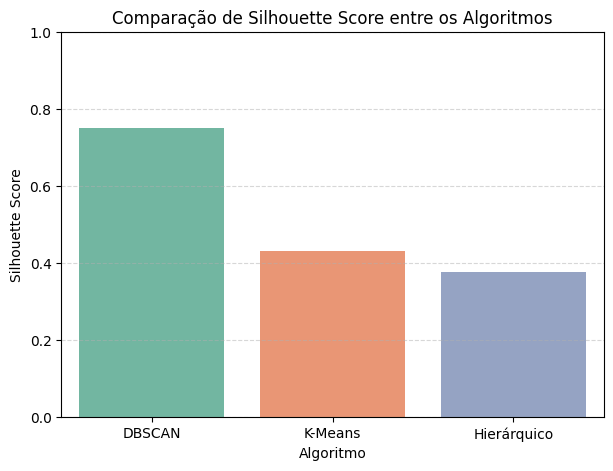

In [52]:
# ---------------------------------------------------
# 6. Comparação dos Métodos
# ---------------------------------------------------

resultados = pd.DataFrame({
    'Algoritmo': ['K-Means', 'DBSCAN', 'Hierárquico'],
    'Silhouette Score': [
        score_kmeans,
        score_dbscan,
        score_hier
    ]
})

# Ordena do maior para o menor
resultados = resultados.sort_values('Silhouette Score', ascending=False).reset_index(drop=True)
print(resultados)

# Gráfico comparativo
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.barplot(data=resultados, x='Algoritmo', y='Silhouette Score', palette='Set2')
plt.title('Comparação de Silhouette Score entre os Algoritmos')
plt.ylim(0, 1)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()
